In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from xgboost import plot_importance




In [2]:
#Display the first few rows ( to show the features we have )
#pregnancies = times pregnant
#glucose = blood sugar level (mg/dl)
#blood pressure = diastolic blood pressure (mm Hg)
#skin thickness = triceps skin fold thickness (mm)
#insulin = serum insulin (mu U/ml)
#BMI = body mass index (weight in kg/(height in m)^2)
#diabetes pedigree function = function which scores likelihood of diabetes based on family history
#age = age of the patient (years)
#outcome = class variable (0 = non-diabetic or 1 = diabetic) 268 of 768 are 1, the others are 0
df = pd.read_csv("diabetes.csv")

#to see how many people have diabetes and how many do not have diabetes in this dataset
print(df["Outcome"].value_counts())

df.head()

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# identify columns with zeros, EXCLUDING 'Outcome'
cols_with_zero = [col for col in df.columns if (df[col] == 0).any() and col != 'Outcome']

#replacing zeros with median values for the identified columns
for col in cols_with_zero:
    df[col] = df[col].replace(0, df[col].median())
# decided filling the NaN values with the median of each column would be the best approach.
# helps to maintain the distribution of the data without introducing bias. (change it later??)
df.fillna(df.median(), inplace=True)

#notice the difference (previously 0 values were replaced )
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,3,137,40,35,168.0,43.1,2.288,33,1


In [4]:
#creating feature matrix (X) and target vector (y)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

#tried the 80/20 rule for splitting data into training and testing sets. Other percentages were tested. Currently going with the 70/30.
#stratify ensures that the proportion of classes is maintained in both training and testing sets.
#used random_state because it gets me the same 70/30 split every time the code is run.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y, random_state=14)

# Standardize the data: transforms each feature to have mean=0 and std=1.
# Important for models that use distance or gradients (SVM, KNN, Logistic Regression).
# Tree-based models (Random Forest, XGBoost) don't need scaling, but others do.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
#logistic regression

# the lower the value of C the less our model can increase weights to fit outliers. The higher the value of C the more we can increase weights to fit outliers.

# l1 = lasso. a penalty that can shrink some coefficients to zero, effectively performing feature selection. l2 = ridge. a penalty that shrinks coefficients but does not set them to zero.

# solver = liblinear can handle both l1 and l2 penalties, making it a good choice for our grid search since I am not yet sure which one will perform better. It is also efficient for small datasets like ours.
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

#testing out different combinations of hyperparameters to find the best model. Using 5-fold cross-validation for now to evaluate each combination.
grid_logreg = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid_logreg.fit(X_train_scaled, y_train)

# Using the best model.
best_logreg = grid_logreg.best_estimator_
y_prob = best_logreg.predict_proba(X_test_scaled)[:, 1]

y_pred_adjusted = (y_prob >= 0.4).astype(int)

print("\n==== Logistic Regression ====")
print("Accuracy:", accuracy_score(y_test, y_pred_adjusted))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_adjusted))



==== Logistic Regression ====
Accuracy: 0.7316017316017316
ROC AUC: 0.8405761316872429
              precision    recall  f1-score   support

           0       0.90      0.66      0.76       150
           1       0.58      0.86      0.69        81

    accuracy                           0.73       231
   macro avg       0.74      0.76      0.73       231
weighted avg       0.79      0.73      0.74       231



In [39]:
#RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}


grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

rf = grid_rf.best_estimator_
print("Best RF Params:", grid_rf.best_params_)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

y_pred_rf_adj = (y_prob_rf >= 0.35).astype(int)

print("\n==== Random Forest ====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_adj))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf_adj))

Best RF Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}

==== Random Forest ====
Accuracy: 0.7532467532467533
ROC AUC: 0.8439506172839505
              precision    recall  f1-score   support

           0       0.88      0.72      0.79       150
           1       0.61      0.81      0.70        81

    accuracy                           0.75       231
   macro avg       0.74      0.77      0.74       231
weighted avg       0.78      0.75      0.76       231



In [34]:
#SVM
#A kernel tells the SVM how to measure similarity between points so it can find a non-linear decision boundary.
#In this case, the RBF kernel allows for non-linear separation.
svm = SVC(kernel='rbf', probability=True, class_weight='balanced')
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)
y_prob = svm.predict_proba(X_test_scaled)[:, 1]

custom_threshold = 0.35
y_pred_adjusted = (y_prob >= custom_threshold).astype(int)

print("==== SVM ====")
print("Accuracy:", accuracy_score(y_test, y_pred_adjusted))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_adjusted))


==== SVM ====
Accuracy: 0.7445887445887446
ROC AUC: 0.8313580246913581
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       150
           1       0.61      0.73      0.67        81

    accuracy                           0.74       231
   macro avg       0.73      0.74      0.73       231
weighted avg       0.76      0.74      0.75       231



In [35]:
#KNN


param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

#cv=5 means 5-fold cross-validation, scoring='recall' means we want to optimize for recall, n_jobs=-1 means use all available CPU cores for parallel processing.
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='recall', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

knn_best = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

custom_threshold = 0.35
y_prob = knn_best.predict_proba(X_test_scaled)[:, 1]
y_pred_adjusted = (y_prob >= custom_threshold).astype(int)

print("\n==== KNN ====")
print("Accuracy:", accuracy_score(y_test, y_pred_adjusted))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_adjusted))

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

==== KNN ====
Accuracy: 0.70995670995671
ROC AUC: 0.7768312757201645
              precision    recall  f1-score   support

           0       0.87      0.65      0.75       150
           1       0.56      0.81      0.66        81

    accuracy                           0.71       231
   macro avg       0.71      0.73      0.70       231
weighted avg       0.76      0.71      0.72       231



==== XGBoost ====
Accuracy: 0.7705627705627706
ROC AUC: 0.8374485596707819
              precision    recall  f1-score   support

           0       0.89      0.73      0.81       150
           1       0.63      0.84      0.72        81

    accuracy                           0.77       231
   macro avg       0.76      0.79      0.76       231
weighted avg       0.80      0.77      0.78       231



<Figure size 1000x600 with 0 Axes>

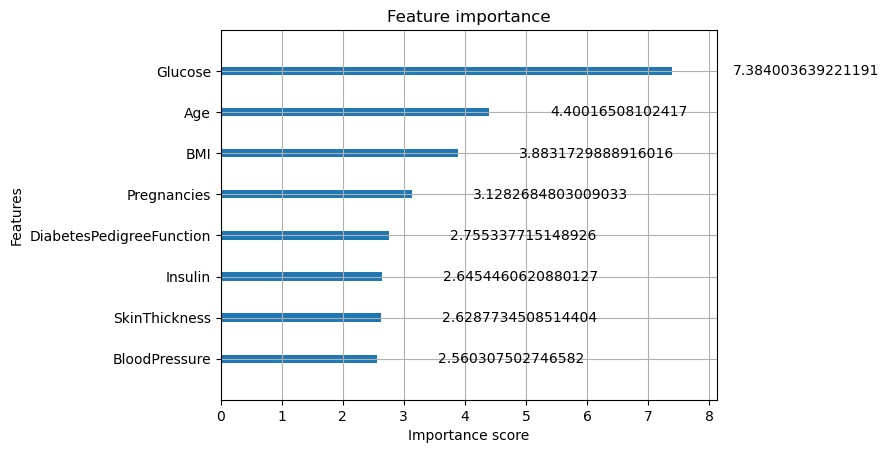

In [36]:
#XGBoost
#
xgb_model = xgb.XGBClassifier(
    n_estimators=500,      
    learning_rate=0.02,     
    max_depth=4,            
    min_child_weight=5,     
    subsample=0.7,          
    colsample_bytree=0.7,  
    gamma=0.2,              
    reg_lambda=2,           
    scale_pos_weight=1.86,  
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

custom_threshold = 0.35
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_prob >= custom_threshold).astype(int)

print("==== XGBoost ====")
print("Accuracy:", accuracy_score(y_test, y_pred_adjusted))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_adjusted))

import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plotting feature importance by 'gain' (the most reliable metric for XGB)
plt.figure(figsize=(10,6))
plot_importance(xgb_model, importance_type='gain', max_num_features=10)
plt.show()


In [ ]:
plt.figure(figsize=(10, 7))

models = {
    "Logistic Regression": logreg,
    "Random Forest": rf,
    "SVM (RBF)": svm,
    "KNN": knn,
    "XGBoost": xgb_model
}

for name, model in models.items():
    if name in ["Random Forest", "XGBoost"]:
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


NameError: name 'rf' is not defined

<Figure size 1000x700 with 0 Axes>